# Regression Trees

A Regression Tree is a non-parametric supervised learning algorithm that predicts a continuous numerical value by recursively partitioning the feature space into smaller, more homogenous regions.

Unlike Linear Regression, which tries to fit a single global equation to the data, a Regression Tree asks a series of "if-then" questions.

The goal at each split is to minimize the Mean Squared Error (MSE) within the resulting branches. By the time the algorithm reaches a "leaf" (a final node), it predicts the average value of all training points that landed in that specific region. This makes trees incredibly powerful for capturing non-linear relationships and interactions between variables without requiring complex feature engineering.


### Setup and Exploration

Before building a model, we must understand the "shape" of our data.

Dataset Selection: We are referencing the AmesHousing.csv file, a comprehensive dataset of residential sales in Ames, Iowa.

Target Distribution: We first plot a histogram of the SalePrice, which helps us identify if the target is skewed or contains outliers.

Correlation Heatmap: This visualization identifies linear relationships. For a Regression Tree, high correlation between a feature (like Overall Qual) and the target suggests that the feature will likely be chosen for a "top-level" split

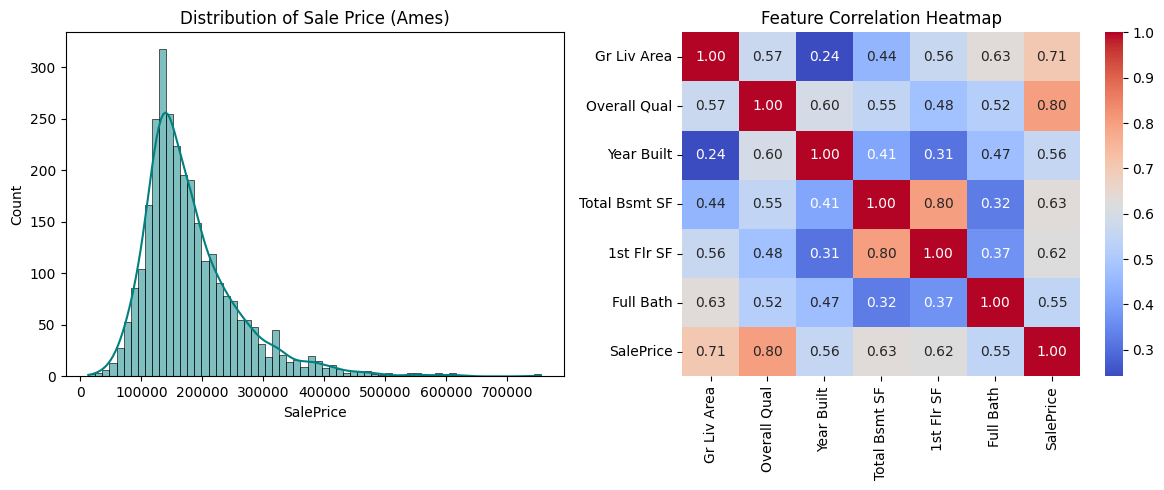

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.model_selection import train_test_split, validation_curve, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Load the Ames Housing dataset
df = pd.read_csv('AmesHousing.csv')

# Selecting key numerical features for the model
features = ['Gr Liv Area', 'Overall Qual', 'Year Built', 'Total Bsmt SF', '1st Flr SF', 'Full Bath']
target = 'SalePrice'
df_clean = df[features + [target]].dropna()

X = df_clean[features]
y = df_clean[target]

# EDA Plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(y, kde=True, color='teal')
plt.title('Distribution of Sale Price (Ames)')

plt.subplot(1, 2, 2)
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### MSE & Splitting

To understand the underlying mechanics, we consider how the tree decides where to split.

Variance Reduction: The algorithm calculates the MSE for different potential split points across features. This demonstrates the "Greedy Search" nature of the algorithm—it looks for the single best split right now to reduce the variance in the child nodes as much as possible.

In [43]:
def calculate_mse(y):
    if len(y) == 0: return 0
    return np.mean((y - np.mean(y))**2)

print(f"Sample MSE for the Ames dataset: {calculate_mse(y):.4f}")

Sample MSE for the Ames dataset: 6378344532.1374


### Validation Curve and Overfitting

One of the biggest risks with trees is overfitting - where the tree grows so deep it memorizes the noise in the training data rather than the actual patterns.

Validation Curve: This figure is the heart of a "Bias-Variance" analysis. By plotting the $R^2$
  score for both training and cross-validation sets across different depths, we can visually identify the optimal.

 If the training score keeps rising while the cross-validation score plateaus or drops, the model is overfitting

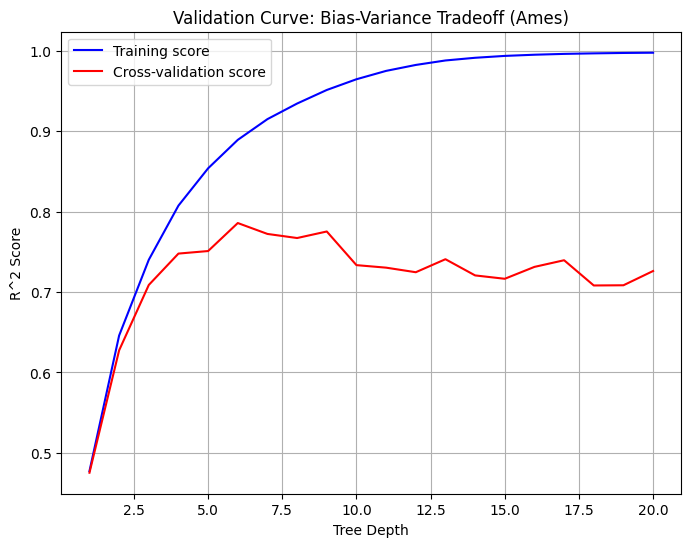

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_range = np.arange(1, 21)
train_scores, test_scores = validation_curve(
    DecisionTreeRegressor(), X_train, y_train,
    param_name="max_depth", param_range=param_range,
    cv=5, scoring="r2", n_jobs=-1
)

plt.figure(figsize=(8, 6))
plt.plot(param_range, np.mean(train_scores, axis=1), label="Training score", color='blue')
plt.plot(param_range, np.mean(test_scores, axis=1), label="Cross-validation score", color='red')
plt.title("Validation Curve: Bias-Variance Tradeoff (Ames)")
plt.xlabel("Tree Depth")
plt.ylabel("R^2 Score")
plt.legend()
plt.grid(True)
plt.show()

### Standard Modeling and Hyperparameter Tuning

We use `GridSearchCV` to scientifically find the best configuration for our model.

Grid Search: Instead of guessing, we test combinations of `max_depth` and `min_samples_leaf`. This ensures our final model is "regularized," meaning it is simple enough to generalize but complex enough to be accurate.

In [45]:
param_grid = {'max_depth': [3, 5, 10, 15], 'min_samples_leaf': [1, 5, 10]}
grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 10}


The final step is to check our errors to see where the model is failing.

Parity Plot (Actual vs. Predicted): A perfect model would show a straight 45-degree line. Deviation from this line shows where our model under-predicts (common for high-value properties) or over-predicts.

Residual Plot: We plot the errors (Residuals) against the predictions. We are looking for a random "cloud" of points.

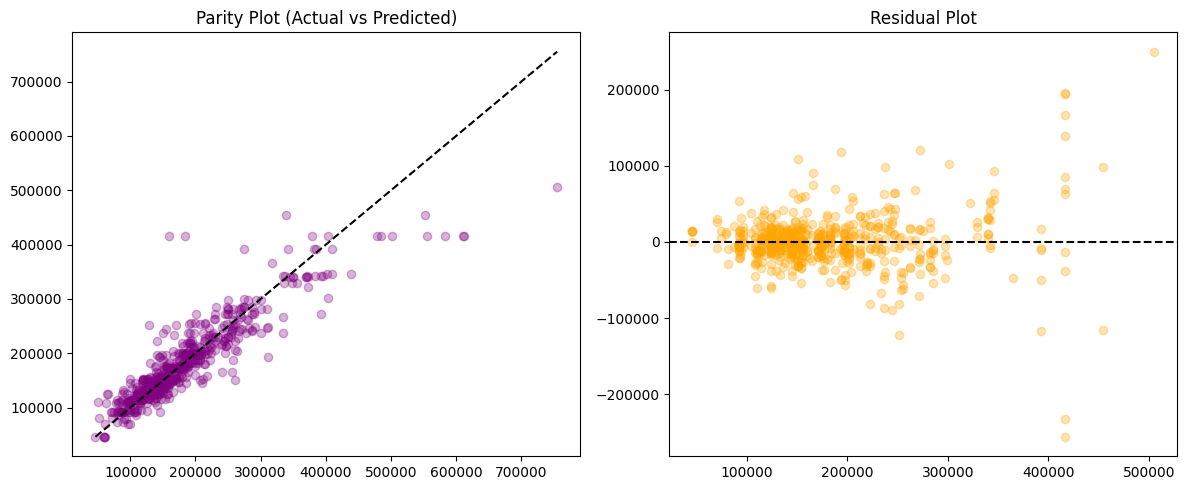

In [46]:
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.3, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--k')
plt.title('Parity Plot (Actual vs Predicted)')

plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.3, color='orange')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

Model Interpretability:

Finally, we output the Tree Structure Logic. This translates the complex mathematical splits back into readable rules. This transparency is a primary reason why decision trees remain popular.

In [47]:
tree_rules = export_text(best_model, feature_names=list(X.columns), max_depth=2)
print("Top-level Decision Rules for Ames Housing:")
print(tree_rules)

Top-level Decision Rules for Ames Housing:
|--- Overall Qual <= 7.50
|   |--- Overall Qual <= 6.50
|   |   |--- Gr Liv Area <= 1379.00
|   |   |   |--- truncated branch of depth 8
|   |   |--- Gr Liv Area >  1379.00
|   |   |   |--- truncated branch of depth 8
|   |--- Overall Qual >  6.50
|   |   |--- Gr Liv Area <= 1993.50
|   |   |   |--- truncated branch of depth 8
|   |   |--- Gr Liv Area >  1993.50
|   |   |   |--- truncated branch of depth 5
|--- Overall Qual >  7.50
|   |--- Overall Qual <= 8.50
|   |   |--- Gr Liv Area <= 1920.50
|   |   |   |--- truncated branch of depth 6
|   |   |--- Gr Liv Area >  1920.50
|   |   |   |--- truncated branch of depth 5
|   |--- Overall Qual >  8.50
|   |   |--- Gr Liv Area <= 1956.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- Gr Liv Area >  1956.50
|   |   |   |--- truncated branch of depth 4



### Conclusion
the simplified takeaways:

- The tree successfully identified Overall Quality and Living Area as the primary drivers of house prices by splitting data to minimize Mean Squared Error (MSE).

- The Validation Curve demonstrated that a max_depth of 10 was the "sweet spot"—preventing the model from being too simple (high bias) or over-memorizing noise (high variance).

- The code handled diverse features, from year built to quality ratings, without needing feature scaling, showcasing the model's natural ability to handle varied data ranges.

- The Parity and Residual plots confirmed the model is generally accurate but struggles with extreme outliers, indicating where a single tree reaches its performance limit.

- While highly interpretable, the "squiggly" nature of the cross-validation score highlights the instability of single trees, motivating the transition to Random Forests

This notebook demonstrated a Regression Tree implemented on the AmesHousing.csv dataset. By analyzing the validation curve and residual diagnostics, we established that tree depth is the primary lever for controlling overfitting. This example serves as a foundation for more complex ensemble methods and neural network models within this project.